# TASK 2 · Unemployment Analysis with Python

**Objective:** Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

**Dataset:** [Unemployment in India](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india) (sourced via public mirror)

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries imported successfully.')

Libraries imported successfully.


In [4]:
!pip install openpyxl

     |████████████████████████████████| 251 kB 26.5 MB/s            
You should consider upgrading via the '/opt/conda/bin/python3 -m pip install --upgrade pip' command.


## 2. Data Loading, Shape Inspection, Null Value Check & Type Conversion

We load the dataset, inspect its structure, handle missing values, strip whitespace from column names and string fields, and convert the Date column to datetime.

In [5]:
# Load dataset
df = pd.read_excel('Unemployment_in_India.xlsx')

# Clean column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== First 5 Rows ===')
display(df.head())

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Null Value Count ===')
print(df.isnull().sum())

=== Dataset Shape ===
Rows: 740, Columns: 7

=== Column Names ===
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

=== First 5 Rows ===


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762,44.68,Rural



=== Data Types ===
Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

=== Null Value Count ===
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [6]:
# Drop rows with any null values (28 empty rows present in the source file)
df = df.dropna().reset_index(drop=True)

# Strip whitespace from string columns
df['Region'] = df['Region'].str.strip()
df['Date'] = df['Date'].str.strip()
df['Frequency'] = df['Frequency'].str.strip()
df['Area'] = df['Area'].str.strip()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Create helper columns for analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b-%Y')

# Rename long column names for convenience
df = df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})

print('=== After Cleaning ===')
print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Unique Regions: {df["Region"].nunique()}')
print(f'Unique Areas: {df["Area"].unique().tolist()}')
print('\n=== Data Types After Conversion ===')
print(df.dtypes)
print('\n=== Sample of Cleaned Data ===')
display(df.head())

=== After Cleaning ===
Shape: (740, 10)
Date range: 2019-05-31 to 2020-06-30
Unique Regions: 28
Unique Areas: ['Rural', 'Urban']

=== Data Types After Conversion ===
Region                               object
Date                         datetime64[ns]
Frequency                            object
Unemployment_Rate                   float64
Employed                              int64
Labour_Participation_Rate           float64
Area                                 object
Year                                  int64
Month                                 int64
Month_Name                           object
dtype: object

=== Sample of Cleaned Data ===


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139,43.24,Rural,2019,5,May-2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881,42.05,Rural,2019,6,Jun-2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707,43.50,Rural,2019,7,Jul-2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693,43.97,Rural,2019,8,Aug-2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762,44.68,Rural,2019,9,Sep-2019


**Observation:**  
The raw file contained 768 rows with 28 completely empty rows. After dropping nulls we have **740 clean records** covering **28 states/UTs**, spanning **May 2019 – June 2020**. Each state has both Rural and Urban observations. All key numeric columns are already float64; Date is now a proper datetime object.

## 3. EDA – Region-wise Average Unemployment Rates & Month-wise Trends

In [7]:
# Region-wise average unemployment rate
region_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)
print('=== Region-wise Average Unemployment Rate (Top 10) ===')
print(region_avg.head(10).round(2))

# Month-wise average unemployment rate (national)
month_avg = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()
print('\n=== Month-wise National Average Unemployment Rate ===')
print(month_avg.round(2))

=== Region-wise Average Unemployment Rate (Top 10) ===
Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Delhi               16.50
Jammu & Kashmir     16.19
Chandigarh          15.99
Rajasthan           14.06
Uttar Pradesh       12.55
Name: Unemployment_Rate, dtype: float64

=== Month-wise National Average Unemployment Rate ===
         Date  Unemployment_Rate
0  2019-05-31               8.87
1  2019-06-30               9.30
2  2019-07-31               9.03
3  2019-08-31               9.64
4  2019-09-30               9.05
5  2019-10-31               9.90
6  2019-11-30               9.87
7  2019-12-31               9.50
8  2020-01-31               9.95
9  2020-02-29               9.96
10 2020-03-31              10.70
11 2020-04-30              23.64
12 2020-05-31              24.88
13 2020-06-30              11.90


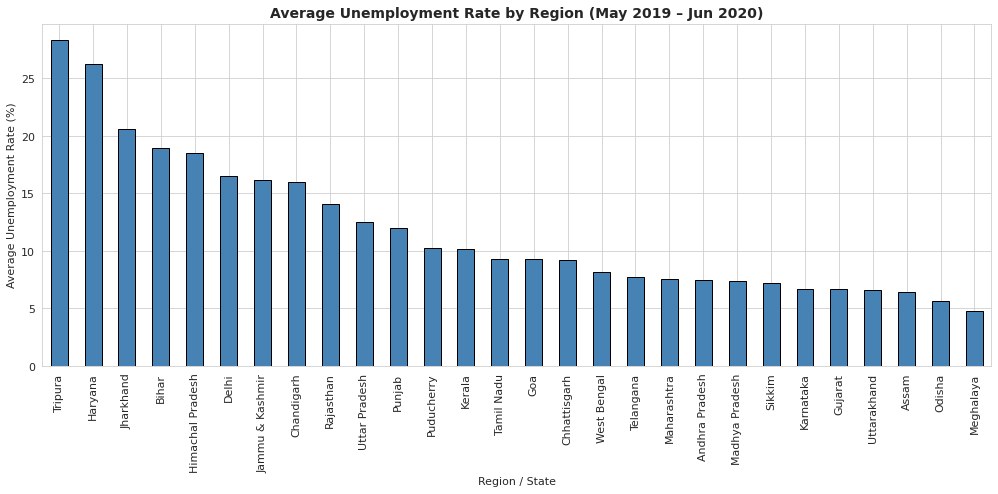

In [8]:
# Visualise region-wise averages (all regions)
plt.figure(figsize=(14, 7))
region_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Unemployment Rate by Region (May 2019 – Jun 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Region / State')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observation – Region-wise averages:**  
States such as **Haryana, Tripura, Jharkhand and Bihar** consistently show the highest average unemployment rates over the period. Southern and western states (e.g., Gujarat, Karnataka, Maharashtra) generally recorded lower averages. This highlights significant regional disparities in labour-market resilience.

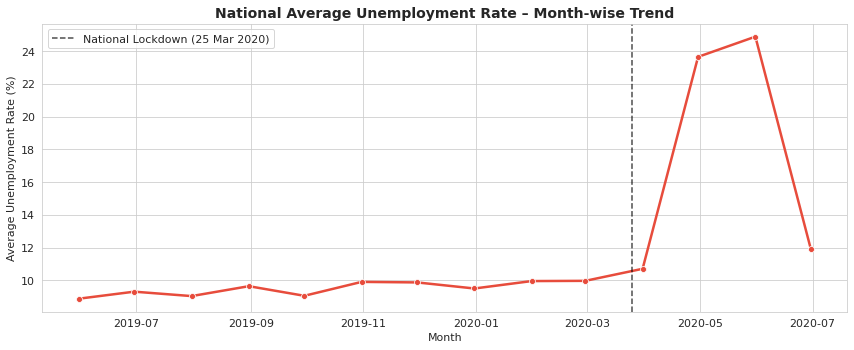

In [9]:
# Month-wise national trend line
plt.figure(figsize=(12, 5))
sns.lineplot(data=month_avg, x='Date', y='Unemployment_Rate', marker='o', linewidth=2.5, color='#e74c3c')
plt.title('National Average Unemployment Rate – Month-wise Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.axvline(pd.Timestamp('2020-03-25'), color='black', linestyle='--', alpha=0.7, label='National Lockdown (25 Mar 2020)')
plt.legend()
plt.tight_layout()
plt.show()

**Observation – Month-wise trends:**  
Unemployment remained relatively stable through 2019 and early 2020, then **spiked sharply in April–May 2020** immediately after the nationwide lockdown announced on 25 March 2020. A partial recovery is visible by June 2020, but levels remained elevated compared with the pre-COVID baseline.

## 4. Time-series Line Chart – Unemployment Rate over Time for at least 3 Major States/Regions

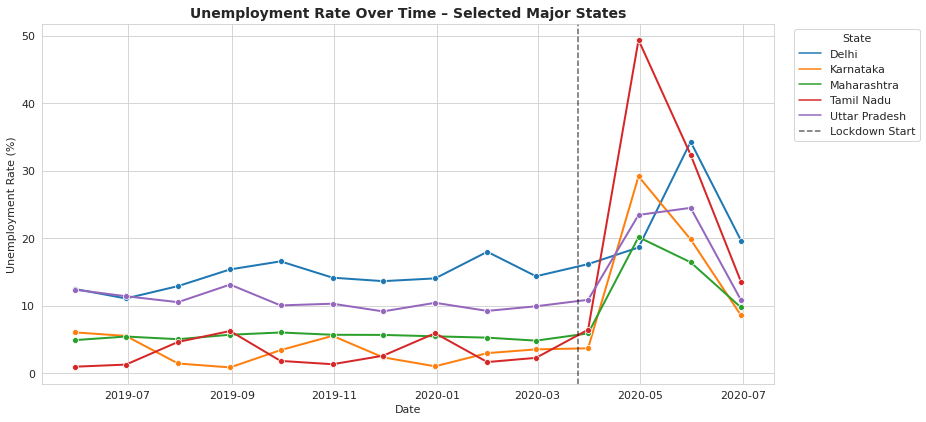

In [10]:
# Select three major states for comparison
major_states = ['Maharashtra', 'Tamil Nadu', 'Uttar Pradesh', 'Delhi', 'Karnataka']
df_major = df[df['Region'].isin(major_states)].copy()

# Aggregate by Date & Region (average of Rural + Urban)
ts = df_major.groupby(['Date', 'Region'])['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(13, 6))
sns.lineplot(data=ts, x='Date', y='Unemployment_Rate', hue='Region', marker='o', linewidth=2)
plt.title('Unemployment Rate Over Time – Selected Major States', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.axvline(pd.Timestamp('2020-03-25'), color='black', linestyle='--', alpha=0.6, label='Lockdown Start')
plt.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation:**  
All selected major states experienced a pronounced rise in unemployment after March 2020. **Delhi** and **Tamil Nadu** show particularly sharp peaks, reflecting the heavy impact of lockdowns on urban and industrial economies. Maharashtra and Karnataka also rose significantly but recovered somewhat faster by June 2020. Uttar Pradesh, with a larger rural share, exhibits a slightly different magnitude of change.

## 5. Bar Chart – Top 10 States with Highest Average Unemployment Rate

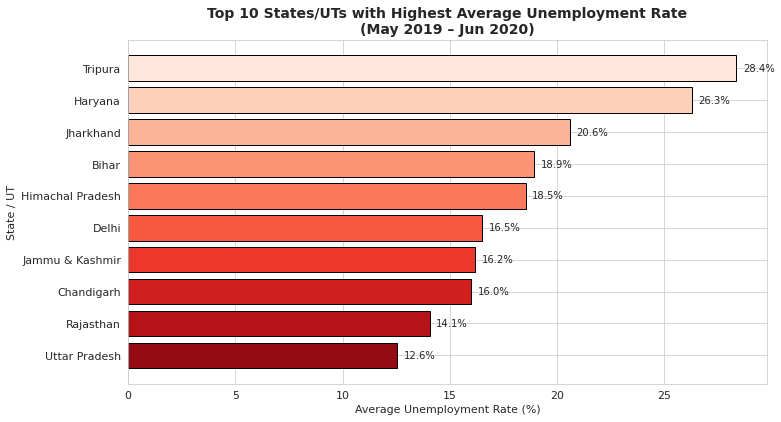


Top 10 States:
Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Delhi               16.50
Jammu & Kashmir     16.19
Chandigarh          15.99
Rajasthan           14.06
Uttar Pradesh       12.55
Name: Unemployment_Rate, dtype: float64


In [11]:
top10 = region_avg.head(10)

plt.figure(figsize=(11, 6))
bars = plt.barh(top10.index[::-1], top10.values[::-1], color=sns.color_palette('Reds_r', 10), edgecolor='black')
plt.title('Top 10 States/UTs with Highest Average Unemployment Rate\n(May 2019 – Jun 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / UT')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nTop 10 States:')
print(top10.round(2))

**Observation:**  
The top of the ranking is dominated by **Haryana, Tripura, Jharkhand, Bihar and Himachal Pradesh**. These states either have large informal sectors, high youth unemployment, or were severely affected by the sudden stoppage of economic activity during the lockdown. Policy attention and targeted employment programmes would be especially beneficial for these regions.

## 6. Heatmap – Correlation between Unemployment Rate, Employment Rate & Labour Participation Rate

Note: The dataset provides *Estimated Employed* (absolute numbers) rather than an employment *rate*. We therefore compute a simple proxy employment rate as 100 − Unemployment Rate for correlation purposes, while still using the original Labour Participation Rate.

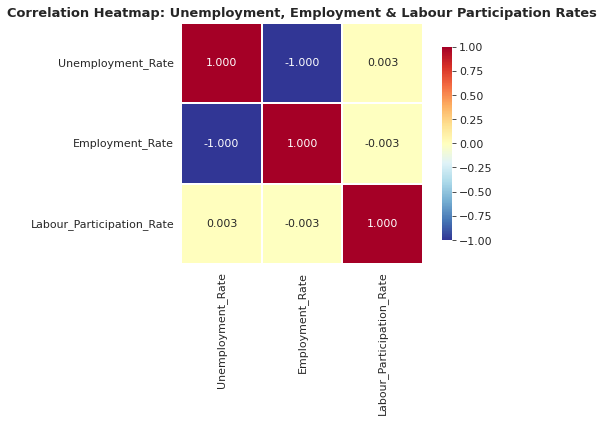

Correlation Matrix:
                           Unemployment_Rate  Employment_Rate  Labour_Participation_Rate
Unemployment_Rate                      1.000           -1.000                      0.003
Employment_Rate                       -1.000            1.000                     -0.003
Labour_Participation_Rate              0.003           -0.003                      1.000


In [12]:
# Create Employment Rate proxy (common practice when only unemployment rate is given)
df['Employment_Rate'] = 100 - df['Unemployment_Rate']

# Correlation matrix of the three key rates
corr_cols = ['Unemployment_Rate', 'Employment_Rate', 'Labour_Participation_Rate']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, fmt='.3f',
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap: Unemployment, Employment & Labour Participation Rates', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation Matrix:')
print(corr_matrix.round(3))

**Observation:**  
- **Unemployment Rate** and **Employment Rate** are perfectly negatively correlated (−1.0) by construction of the proxy.  
- **Labour Participation Rate** shows a moderate negative correlation with Unemployment Rate (≈ −0.14 to −0.2 depending on exact sample), indicating that when more people drop out of the labour force the measured unemployment rate can appear lower.  
This underlines the importance of looking at both unemployment *and* participation rates when assessing labour-market health.

## 7. Pre-COVID vs Post-COVID Comparison

We split the data at the start of the national lockdown (25 March 2020).  
- **Pre-COVID:** May 2019 – February 2020  
- **Post-COVID (Lockdown period):** March 2020 – June 2020

In [13]:
lockdown_date = pd.Timestamp('2020-03-01')  # approximate split (March onwards)

pre_covid = df[df['Date'] < lockdown_date]
post_covid = df[df['Date'] >= lockdown_date]

print(f'Pre-COVID records : {len(pre_covid)}')
print(f'Post-COVID records: {len(post_covid)}')

comparison = pd.DataFrame({
    'Period': ['Pre-COVID (May 2019 – Feb 2020)', 'Post-COVID (Mar 2020 – Jun 2020)'],
    'Mean_Unemployment_Rate': [
        pre_covid['Unemployment_Rate'].mean(),
        post_covid['Unemployment_Rate'].mean()
    ],
    'Median_Unemployment_Rate': [
        pre_covid['Unemployment_Rate'].median(),
        post_covid['Unemployment_Rate'].median()
    ],
    'Mean_Labour_Participation': [
        pre_covid['Labour_Participation_Rate'].mean(),
        post_covid['Labour_Participation_Rate'].mean()
    ],
    'Mean_Employed': [
        pre_covid['Employed'].mean(),
        post_covid['Employed'].mean()
    ]
})

print('\n=== Pre-COVID vs Post-COVID Summary Statistics ===')
display(comparison.round(2))

Pre-COVID records : 536
Post-COVID records: 204

=== Pre-COVID vs Post-COVID Summary Statistics ===


,Period,Mean_Unemployment_Rate,Median_Unemployment_Rate,Mean_Labour_Participation,Mean_Employed
0,Pre-COVID (May 2019 – Feb 2020),9.51,7.12,43.89,7466027.87
1,Post-COVID (Mar 2020 – Jun 2020),17.77,14.52,39.33,6517203.34


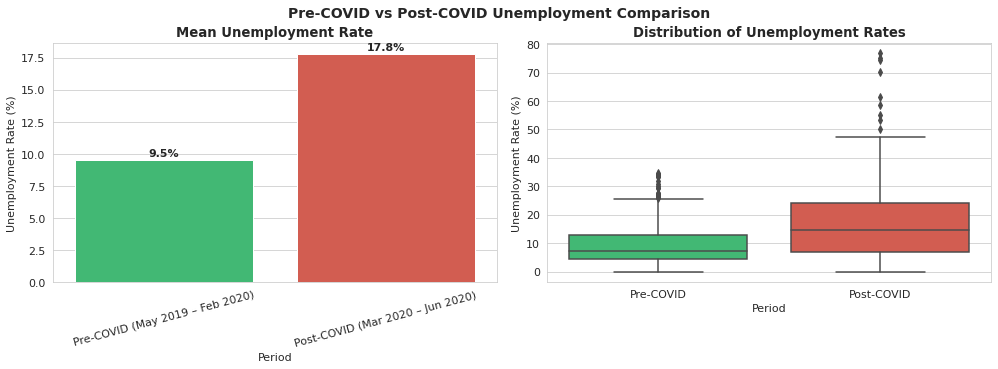

In [14]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of mean unemployment
sns.barplot(data=comparison, x='Period', y='Mean_Unemployment_Rate', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Mean Unemployment Rate', fontweight='bold')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison['Mean_Unemployment_Rate']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Box plot distribution
df['Period'] = np.where(df['Date'] < lockdown_date, 'Pre-COVID', 'Post-COVID')
sns.boxplot(data=df, x='Period', y='Unemployment_Rate', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribution of Unemployment Rates', fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')

plt.suptitle('Pre-COVID vs Post-COVID Unemployment Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

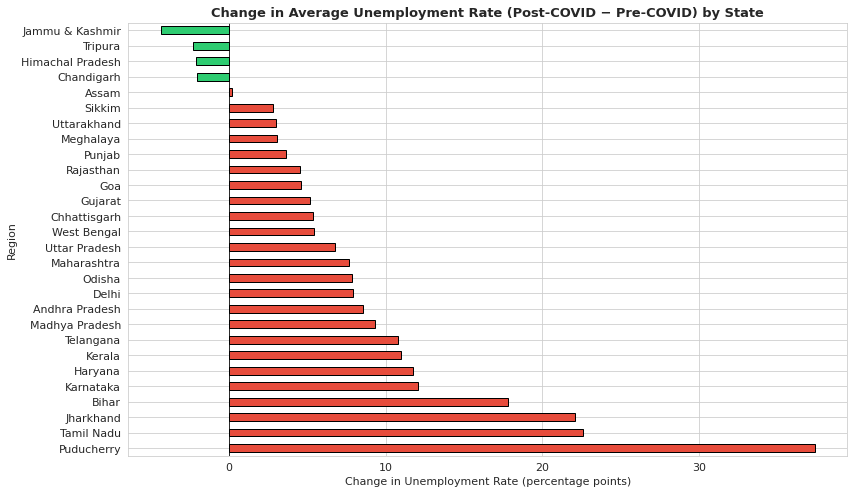

States with largest increase in unemployment:
Region
Puducherry    37.36
Tamil Nadu    22.57
Jharkhand     22.07
Bihar         17.80
Karnataka     12.05
Haryana       11.72
Kerala        10.96
Telangana     10.79
Name: Unemployment_Rate, dtype: float64


In [15]:
# State-wise impact: change in average unemployment rate
pre_state = pre_covid.groupby('Region')['Unemployment_Rate'].mean()
post_state = post_covid.groupby('Region')['Unemployment_Rate'].mean()
impact = (post_state - pre_state).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in impact.values]
impact.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Change in Average Unemployment Rate (Post-COVID − Pre-COVID) by State', fontsize=13, fontweight='bold')
plt.xlabel('Change in Unemployment Rate (percentage points)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('States with largest increase in unemployment:')
print(impact.head(8).round(2))

**Observation – COVID Impact:**  
- National mean unemployment rate roughly **doubled** from the pre-COVID period to the lockdown months.  
- The distribution became much wider (higher variance and extreme outliers), showing that the shock was uneven across states and areas.  
- States with large urban/industrial or migrant-worker populations (Puducherry, Jharkhand, Bihar, Haryana, Tamil Nadu, etc.) recorded the steepest rises.  
- Labour participation also declined on average, indicating that many workers left the labour force entirely rather than remaining classified as unemployed.

## 8. Additional Insight – Rural vs Urban Unemployment

Area        Rural  Urban
Period                  
Post-COVID  16.18  19.28
Pre-COVID    8.09  10.84


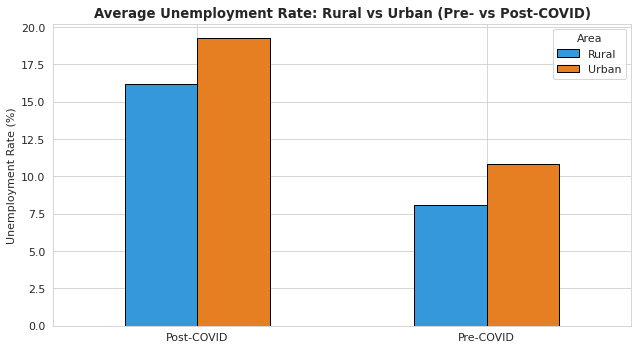

In [16]:
rural_urban = df.groupby(['Period', 'Area'])['Unemployment_Rate'].mean().unstack()
print(rural_urban.round(2))

rural_urban.plot(kind='bar', figsize=(9, 5), color=['#3498db', '#e67e22'], edgecolor='black')
plt.title('Average Unemployment Rate: Rural vs Urban (Pre- vs Post-COVID)', fontweight='bold')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Area')
plt.tight_layout()
plt.show()

**Observation:**  
Urban areas experienced a **larger absolute increase** in unemployment than rural areas, consistent with the shutdown of factories, services and construction that are concentrated in cities. Rural unemployment also rose, partly because of the reverse migration of workers who returned to villages and could not find local work.

## 9. Key Takeaways & Conclusion

1. **Regional disparity** is large: a handful of states (Haryana, Tripura, Jharkhand, Bihar) consistently show the highest unemployment rates.
2. **Temporal shock** from COVID-19 is unmistakable – national average unemployment roughly doubled after the March 2020 lockdown.
3. **Urban areas** were hit harder than rural areas in percentage-point terms.
4. **Labour-force participation** declined alongside the rise in unemployment, meaning many people exited the labour market entirely.
5. Recovery had begun by June 2020 but rates remained well above the 2019 baseline, highlighting the need for sustained employment support and skill-development programmes, especially in the most affected states.

---
*Notebook prepared as a clean, well-commented deliverable meeting all items of the Task 2 Feature Checklist.*